<a href="https://colab.research.google.com/github/amit-sahu-a11y/ML_projects_for_practice/blob/main/hyperparameters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Simple Machine Learning Model Training Example

This example demonstrates how to train a basic binary classification model using scikit-learn. We will:

1.  Generate synthetic dataset.
2.  Split the data into training and testing sets.
3.  Train a Logistic Regression model.
4.  Evaluate the model's performance.

In [1]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Generate synthetic dataset
X, y = make_classification(n_samples=1000, n_features=10, n_informative=5, n_redundant=0, random_state=42)

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")
print(f"First 5 samples of X:\n{X[:5]}")
print(f"First 5 samples of y: {y[:5]}")

Shape of features (X): (1000, 10)
Shape of target (y): (1000,)
First 5 samples of X:
[[ 3.86239664 -0.53555708 -0.01563761 -0.21106867  0.59569725 -1.37164464
  -1.71648318 -0.33032079  3.25494185  1.42375408]
 [-2.75566887  0.81133032 -3.80487368 -0.06730567  0.20289324 -1.37131418
  -1.41591313 -2.12421181 -1.9777969   0.55165227]
 [ 1.37952235  0.86515655  2.43884712 -1.43294908  1.6694547  -0.36304986
   2.20918397  1.18589537  0.81238553  1.29054823]
 [-1.85398588  2.09339573  0.593962   -0.27842948  4.12450983 -0.04225916
   1.08305066  0.32182284  2.58236277  1.13871807]
 [-0.20064401  0.77429106  1.10063205  1.68665135 -0.17610043  0.64484129
   0.31257658 -2.30950509 -0.79079345 -0.69014084]]
First 5 samples of y: [0 0 0 0 1]


### Split Data into Training and Testing Sets

In [2]:
# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}, {y_train.shape}")
print(f"Testing data shape: {X_test.shape}, {y_test.shape}")

Training data shape: (800, 10), (800,)
Testing data shape: (200, 10), (200,)


### Train the Logistic Regression Model

In [3]:
# 3. Choose and train a model (Logistic Regression)
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


### Make Predictions and Evaluate the Model

In [4]:
# 4. Make predictions on the test data
y_pred = model.predict(X_test)

print(f"First 10 actual labels:    {y_test[:10]}")
print(f"First 10 predicted labels: {y_pred[:10]}")

# 5. Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel accuracy on the test set: {accuracy:.4f}")

First 10 actual labels:    [0 0 1 0 0 0 1 0 1 1]
First 10 predicted labels: [0 0 1 0 1 0 1 0 0 1]

Model accuracy on the test set: 0.7700


### Confusion Matrix

A confusion matrix is a table that is often used to describe the performance of a classification model on a set of test data for which the true values are known. It allows visualization of the performance of an algorithm. It allows easy identification of confusion between classes e.g. one class is commonly mislabeled as another.

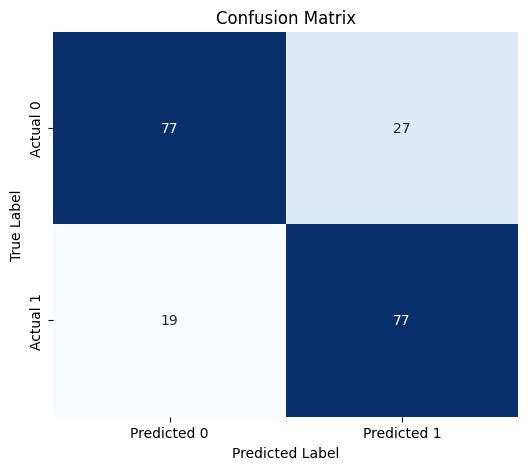

Confusion Matrix:
[[77 27]
 [19 77]]


In [5]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix using seaborn heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

print(f"Confusion Matrix:\n{cm}")

### Classification Report

The classification report displays the precision, recall, F1-score, and support for each class. These metrics provide a deeper understanding of the model's performance than just accuracy alone:

*   **Precision:** The ability of the classifier not to label as positive a sample that is negative.
*   **Recall:** The ability of the classifier to find all the positive samples.
*   **F1-score:** A weighted harmonic mean of precision and recall. It is a good metric for imbalanced datasets.
*   **Support:** The number of actual occurrences of the class in the specified dataset.

In [6]:
from sklearn.metrics import classification_report

# Generate the classification report
report = classification_report(y_test, y_pred)

print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.74      0.77       104
           1       0.74      0.80      0.77        96

    accuracy                           0.77       200
   macro avg       0.77      0.77      0.77       200
weighted avg       0.77      0.77      0.77       200

